In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder

# Load Customer Churn Dataset (no download needed!)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print(df.head())
print("\nData Types:")
print(df.dtypes)

Shape: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

In [6]:
# Check categorical columns
print("Categorical Columns:")
print(df.select_dtypes(include='str').columns.tolist())

print("\nNumerical Columns:")
print(df.select_dtypes(include=['int64','float64']).columns.tolist())

# In Titanic:
# Nominal (no order): Sex, Embarked, Name
# Ordinal (has order): Pclass (1st > 2nd > 3rd)

Categorical Columns:
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

Numerical Columns:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [7]:
# Label Encoding for 'Sex' column
le = LabelEncoder()
df['Sex_encoded'] = le.fit_transform(df['Sex'])

print("Sex Label Encoding:")
print(df[['Sex', 'Sex_encoded']].head(10))
# male = 1, female = 0

Sex Label Encoding:
      Sex  Sex_encoded
0    male            1
1  female            0
2  female            0
3  female            0
4    male            1
5    male            1
6    male            1
7    male            1
8  female            0
9  female            0


In [8]:
# One Hot Encoding for 'Embarked' column
df_encoded = pd.get_dummies(df, columns=['Embarked'], 
                             prefix='Embarked')

print("After One Hot Encoding:")
print(df_encoded[['Embarked_C','Embarked_Q','Embarked_S']].head())

After One Hot Encoding:
   Embarked_C  Embarked_Q  Embarked_S
0       False       False        True
1        True       False       False
2       False       False        True
3       False       False        True
4       False       False        True


In [9]:
# Drop first column to avoid Dummy Variable Trap
df_encoded = pd.get_dummies(df, columns=['Embarked'],
                             prefix='Embarked',
                             drop_first=True)

print("After dropping first dummy:")
print(df_encoded[['Embarked_Q','Embarked_S']].head())

After dropping first dummy:
   Embarked_Q  Embarked_S
0       False        True
1       False       False
2       False        True
3       False        True
4       False        True


In [10]:
# Select numerical columns
num_cols = ['Age', 'Fare']

# Fill missing values first
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# StandardScaler (Standardization)
scaler_std = StandardScaler()
df_standard = df.copy()
df_standard[num_cols] = scaler_std.fit_transform(df[num_cols])

# MinMaxScaler (Normalization)
scaler_mm = MinMaxScaler()
df_minmax = df.copy()
df_minmax[num_cols] = scaler_mm.fit_transform(df[num_cols])

print("Original Age stats:")
print(df['Age'].describe())
print("\nStandardized Age stats:")
print(df_standard['Age'].describe())
print("\nNormalized Age stats:")
print(df_minmax['Age'].describe())

Original Age stats:
count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64

Standardized Age stats:
count    8.910000e+02
mean     2.272780e-16
std      1.000562e+00
min     -2.224156e+00
25%     -5.657365e-01
50%     -1.046374e-01
75%      4.333115e-01
max      3.891554e+00
Name: Age, dtype: float64

Normalized Age stats:
count    891.000000
mean       0.363679
std        0.163605
min        0.000000
25%        0.271174
50%        0.346569
75%        0.434531
max        1.000000
Name: Age, dtype: float64


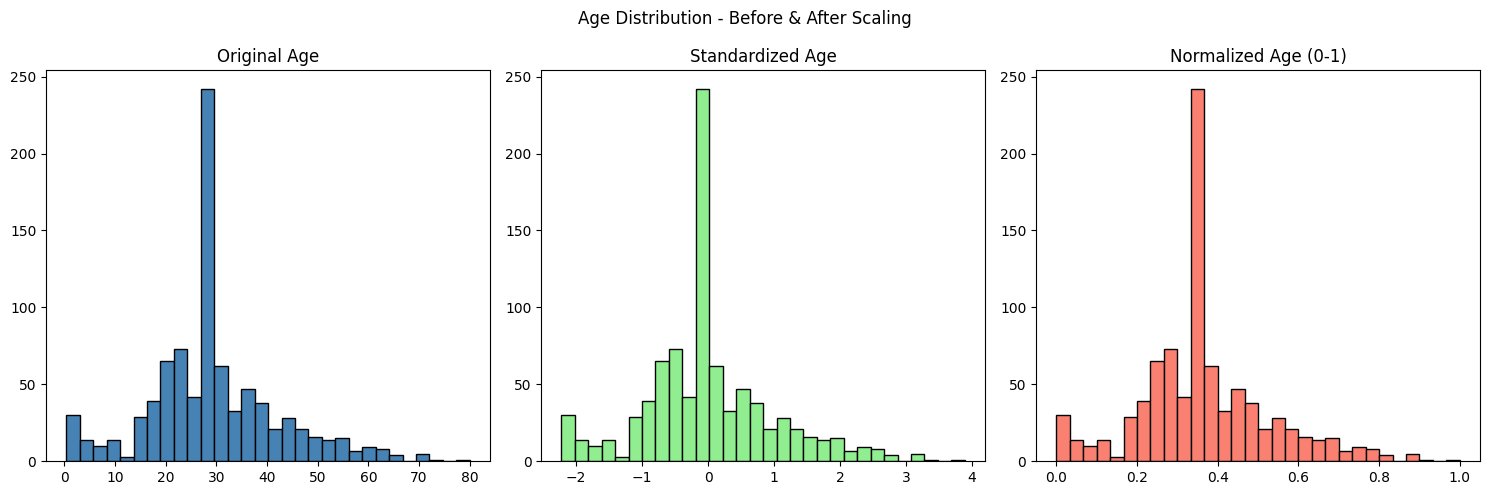

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original
axes[0].hist(df['Age'], bins=30, color='steelblue', 
             edgecolor='black')
axes[0].set_title('Original Age')

# Standardized
axes[1].hist(df_standard['Age'], bins=30, color='lightgreen',
             edgecolor='black')
axes[1].set_title('Standardized Age')

# Normalized
axes[2].hist(df_minmax['Age'], bins=30, color='salmon',
             edgecolor='black')
axes[2].set_title('Normalized Age (0-1)')

plt.suptitle('Age Distribution - Before & After Scaling')
plt.tight_layout()
plt.show()

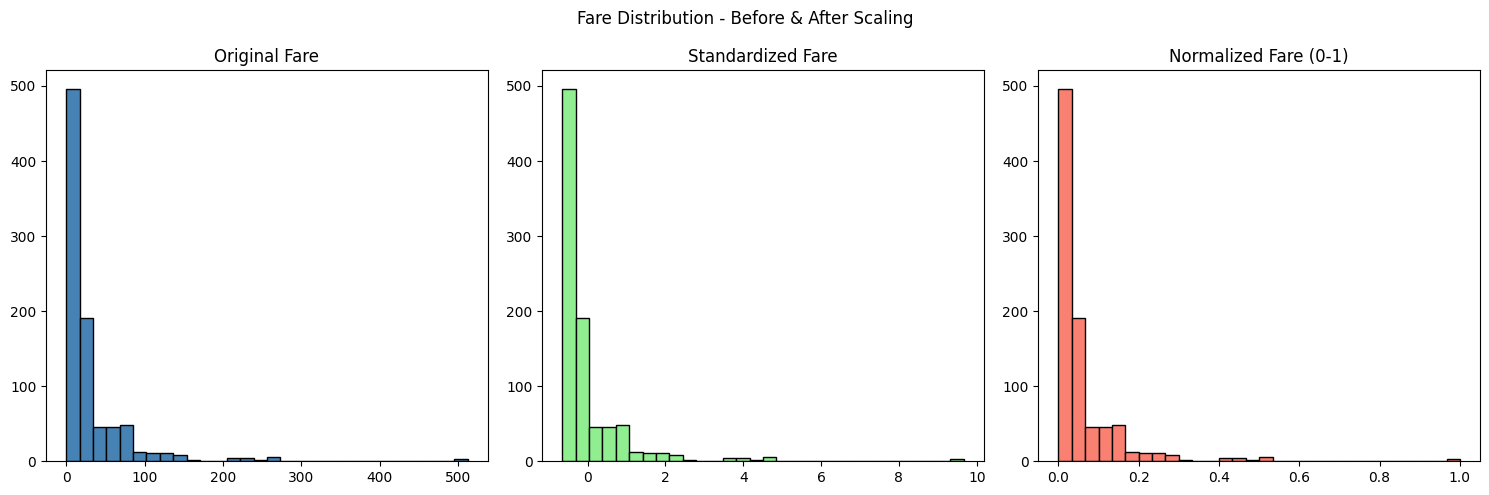

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(df['Fare'], bins=30, color='steelblue',
             edgecolor='black')
axes[0].set_title('Original Fare')

axes[1].hist(df_standard['Fare'], bins=30, color='lightgreen',
             edgecolor='black')
axes[1].set_title('Standardized Fare')

axes[2].hist(df_minmax['Fare'], bins=30, color='salmon',
             edgecolor='black')
axes[2].set_title('Normalized Fare (0-1)')

plt.suptitle('Fare Distribution - Before & After Scaling')
plt.tight_layout()
plt.show()

## 📊 Task 4 Summary - Feature Encoding & Scaling

### Dataset: Titanic (891 rows × 12 columns)

### Encoding Applied:
| Column   | Type    | Encoding Used  |
|----------|---------|----------------|
| Sex      | Nominal | Label Encoding |
| Embarked | Nominal | One-Hot Encoding|
| Pclass   | Ordinal | Already Numeric |

### Scaling Applied:
| Column | Before      | After Standard | After MinMax |
|--------|-------------|----------------|--------------|
| Age    | 0.42 - 80   | mean=0, std=1  | 0 to 1       |
| Fare   | 0 - 512     | mean=0, std=1  | 0 to 1       |

### Why These Techniques?
- Label Encoding → Sex (only 2 categories)
- One-Hot Encoding → Embarked (3 categories, no order)
- drop_first=True → Avoid Dummy Variable Trap
- StandardScaler → When data is normally distributed
- MinMaxScaler → When need values between 0 and 1

## 🎯 Interview Questions & Answers

### Q1. Difference between Label Encoding & One-Hot Encoding?
- **Label Encoding:** Converts categories to numbers
  - Example: male=1, female=0
  - Use for: Ordinal data (has order)
  - Problem: Creates false order in nominal data
- **One-Hot Encoding:** Creates new column per category
  - Example: Embarked_C, Embarked_Q, Embarked_S
  - Use for: Nominal data (no order)
  - Better for ML algorithms

### Q2. Standardization vs Normalization?
- **Standardization (StandardScaler):**
  - Converts to mean=0, std=1
  - Use when: Data is normally distributed
  - Formula: (x - mean) / std
- **Normalization (MinMaxScaler):**
  - Converts to range 0 to 1
  - Use when: Need fixed range
  - Formula: (x - min) / (max - min)

### Q3. What is Dummy Variable Trap?
- When One-Hot Encoding creates multicollinearity
- Example: If Embarked_C=0 & Embarked_Q=0
  then Embarked_S must be 1 (redundant!)
- Solution: Use drop_first=True to drop one column

### Q4. Why do distance-based algorithms need scaling?
- KNN, SVM use distance to find nearest neighbors
- Without scaling: Fare(0-512) dominates Age(0-80)
- With scaling: All features equally important
- Always scale before using KNN, SVM, K-Means

### Q5. One-Hot Encoding for high cardinality features?
- High cardinality = many unique values
- Example: City column with 1000 cities
- Problem: Creates 1000 new columns!
- Solutions:
  - Target Encoding
  - Frequency Encoding
  - Embedding (for deep learning)
  - Group rare categories into "Other"